In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns

#load data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleanup
df['job_posted_date'] =pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)


c:\Users\ADMIN\anaconda3\envs\python_4_data_analytics\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Filter jobs in Vietnam
df_VN = df[df['job_country'] == 'Vietnam' ]

df_VN

In [ ]:
# explode job_skills column 
df_skills = df_VN.explode('job_skills')

df_skills[['job_title','job_skills']]

,job_title,job_skills
1203,"Expert, Data Engineering (40000062)",sql
1203,"Expert, Data Engineering (40000062)",nosql
1203,"Expert, Data Engineering (40000062)",python
1203,"Expert, Data Engineering (40000062)",r
1203,"Expert, Data Engineering (40000062)",scala
...,...,...
785609,Data Engineer,nosql
785609,Data Engineer,postgresql
785609,Data Engineer,mysql
785609,Data Engineer,spark


In [ ]:
# count number of skill for each job and sort it 
df_skills_count =df_skills.groupby(['job_skills','job_title_short']).size()

df_skills_count = df_skills_count.reset_index(name='skill_count')

df_skills_count.sort_values(by='skill_count',ascending=False,inplace=True)

df_skills_count

,job_skills,job_title_short,skill_count
719,sql,Data Engineer,477
550,python,Data Engineer,468
692,spark,Data Engineer,282
301,java,Data Engineer,231
551,python,Data Scientist,230
...,...,...,...
815,watson,Data Engineer,1
271,graphql,Data Analyst,1
273,graphql,Machine Learning Engineer,1
30,atlassian,Senior Data Engineer,1


In [ ]:
# Get top 3 most skill-included job 
job_titles =df_skills_count['job_title_short'].unique().tolist()

job_titles = sorted(job_titles[:3])

job_titles

['Data Analyst', 'Data Engineer', 'Data Scientist']

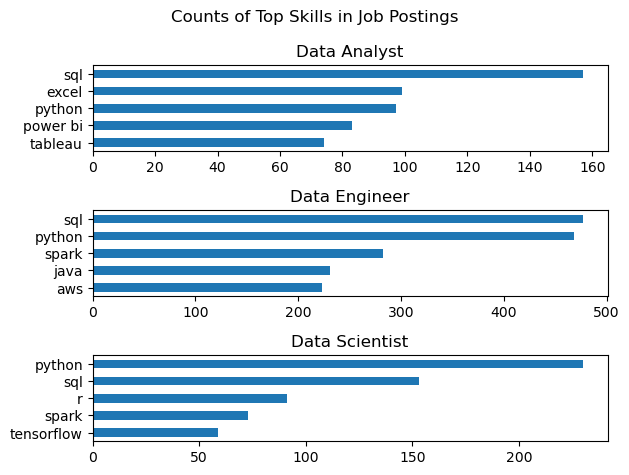

In [16]:
fig, ax = plt.subplots(len(job_titles),1)

for i,job_title in enumerate (job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title ].head(5)
    df_plot.plot(kind='barh',x='job_skills',y='skill_count',ax=ax[i],title = job_title)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
fig.suptitle('Counts of Top Skills in Job Postings')
plt.tight_layout()
plt.show()
    